# KMeans 개선안 4: 실루엣 점수 평가 추가

inertia는 k가 커질수록 감소하므로 단독으로는 판단이 어렵습니다. 실루엣 점수를 함께 계산해 군집 분리 정도를 비교합니다.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

data_path = Path('fruits_300.npy')
if not data_path.exists():
    urlretrieve('https://bit.ly/fruits_300_data', data_path)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100 * 100) / 255.0
fruits_pca = PCA(n_components=50, random_state=42).fit_transform(fruits_2d)


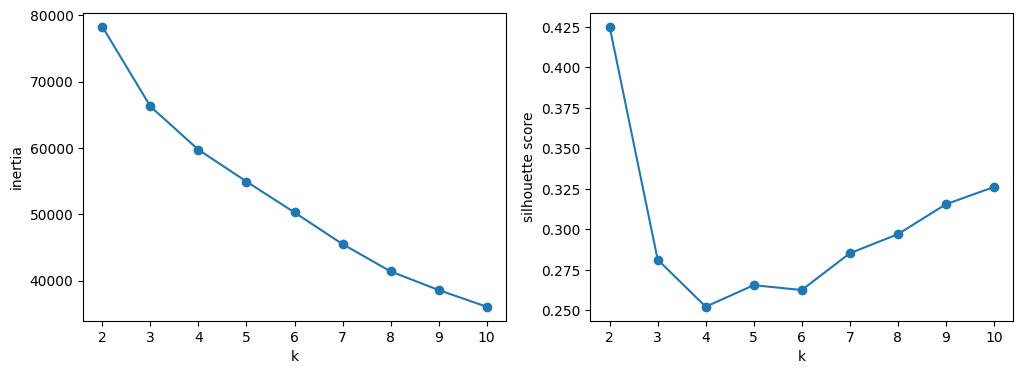

best k by silhouette: 2


In [3]:
k_values = range(2, 11)
inertia = []
silhouette = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(fruits_pca)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(fruits_pca, labels))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(k_values, inertia, marker='o')
axs[0].set_xlabel('k')
axs[0].set_ylabel('inertia')
axs[0].set_xticks(list(k_values))

axs[1].plot(k_values, silhouette, marker='o')
axs[1].set_xlabel('k')
axs[1].set_ylabel('silhouette score')
axs[1].set_xticks(list(k_values))
plt.show()

best_k = list(k_values)[int(np.argmax(silhouette))]
print('best k by silhouette:', best_k)
